In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, QuantileTransformer, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error,classification_report, f1_score, accuracy_score, roc_curve, auc, precision_recall_curve
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from sklearn.manifold import TSNE
# from skopt import BayesSearchCV
# from skopt.space import Real, Integer, Categorical
import scipy.stats as stats
from catboost import CatBoostRegressor, Pool, CatBoostClassifier

In [3]:
pd.set_option('display.max_columns',None)

In [4]:
df = pd.read_csv('/content/df_train_2_FE.csv')

df_val = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Datasets/df_val_2_FE_sinOutliers.csv')

df.dropna(inplace=True)

df['key'] = df['key'].astype(str)
df['mode'] = df['mode'].astype(str)
df['grupo_anio'] = df['grupo_anio'].astype(str)
df['len_playlist_name'] = df['len_playlist_name'].astype(str)
df['tonality'] = df['tonality'].astype(str)

df['distance_mean_duration_min'] = (df['duration_min'] - df['duration_min'].mean())
df['distance_sq_mean_duration_min'] = (df['distance_mean_duration_min'])**2
df['log_duration_min'] = np.log(df['duration_min'])
df['z_duration_min'] = (df['duration_min'] - df['duration_min'].mean())/df['duration_min'].std()

df_val = df_val.drop(columns=['duration_min','duration_mins'])
df_val['loudness'] = df_val['new_loudness']
df_val['liveness'] = df_val['new_liveness']
df_val['duration_min'] = df_val['new_duration_mins']
df_val['distance_mean_duration_min'] = (df_val['duration_min'] - df['duration_min'].mean())
df_val['distance_sq_mean_duration_min'] = (df_val['distance_mean_duration_min'])**2
df_val['log_duration_min'] = np.log(df_val['duration_min'])
df_val['z_duration_min'] = (df_val['duration_min'] - df['duration_min'].mean())/df['duration_min'].std()

### Modelo sacando genres

In [20]:
cols_duration_ms = [col for col in df.columns if 'ms' in col]
cols_drop = cols_duration_ms + ['Unnamed: 0', 'playlist_subgenre', 'key', 'mode', 'anio', 'es0','track_popularity_bins', 'track_id',
                                'track_name', 'track_album_id','track_album_name', 'track_album_release_date', 'playlist_name',
                                'playlist_id']

df_genres = df.drop(columns=cols_drop)

In [21]:
generos = df_genres['playlist_genre'].unique()
for gen in generos:
  print(f'Modelo SIN genero {gen}')
  X = df_genres.loc[df_genres['playlist_genre'] != gen].drop(columns=['playlist_genre', 'track_popularity'])
  y = df_genres.loc[df_genres['playlist_genre'] != gen]['track_popularity']
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
  X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
  cat_features = X.select_dtypes(include='object').columns.tolist()
  train_pool = Pool(X_train, y_train, cat_features=cat_features)
  val_pool = Pool(X_val, y_val, cat_features=cat_features)

  model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.015,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=500,
    early_stopping_rounds=200
  )

  # ── ENTRENAMIENTO ──────────────────────────────────────────────
  model.fit(train_pool, eval_set=val_pool)

  print('TRAIN')
  y_pred = model.predict(X_train)
  print(f"R²:   {r2_score(y_train, y_pred):.4f}")
  print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred)):.4f}")

  print('VAL')
  y_pred = model.predict(X_val)
  print(f"R²:   {r2_score(y_val, y_pred):.4f}")
  print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred)):.4f}")

  print('TEST')
  y_pred = model.predict(X_test)
  print(f"R²:   {r2_score(y_test, y_pred):.4f}")
  print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

  print('\n')

Modelo SIN genero pop
0:	learn: 0.0057026	test: 0.0065146	best: 0.0065146 (0)	total: 54.3ms	remaining: 54.2s
500:	learn: 0.3144323	test: 0.3149600	best: 0.3149600 (500)	total: 20.8s	remaining: 20.7s
999:	learn: 0.3703635	test: 0.3355428	best: 0.3355428 (999)	total: 54.6s	remaining: 0us

bestTest = 0.3355428234
bestIteration = 999

TRAIN
R²:   0.5642
RMSE: 16.3950
VAL
R²:   0.3355
RMSE: 20.3404
TEST
R²:   0.3598
RMSE: 19.9299


Modelo SIN genero rap
0:	learn: 0.0055441	test: 0.0066178	best: 0.0066178 (0)	total: 45.7ms	remaining: 45.6s
500:	learn: 0.3468625	test: 0.3631720	best: 0.3631760 (499)	total: 25s	remaining: 24.9s
999:	learn: 0.4026471	test: 0.3732284	best: 0.3732810 (997)	total: 1m 5s	remaining: 0us

bestTest = 0.3732809849
bestIteration = 997

Shrink model to first 998 iterations.
TRAIN
R²:   0.6079
RMSE: 15.9242
VAL
R²:   0.3733
RMSE: 20.2250
TEST
R²:   0.3793
RMSE: 19.9647


Modelo SIN genero rock
0:	learn: 0.0061324	test: 0.0044828	best: 0.0044828 (0)	total: 71.8ms	remaining

Pop y latin son las mas importantes

Predecimos: modelo sin genero rap ni rock

In [22]:
gen = 'rap'
gen2 = 'rock'
print(f'Modelo SIN genero {gen} ni {gen2}')
X = df_genres.loc[(df_genres['playlist_genre'] != gen) & (df_genres['playlist_genre'] != gen2)].drop(columns=['playlist_genre', 'track_popularity'])
y = df_genres.loc[(df_genres['playlist_genre'] != gen) & (df_genres['playlist_genre'] != gen2)]['track_popularity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
cat_features = X.select_dtypes(include='object').columns.tolist()
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

model = CatBoostRegressor(
  iterations=1000,
  learning_rate=0.02,
  loss_function='RMSE',
  eval_metric='R2',
  random_seed=42,
  verbose=500,
  early_stopping_rounds=200
)
model.fit(train_pool, eval_set=val_pool)

print('TRAIN')
y_pred = model.predict(X_train)
print(f"R²:   {r2_score(y_train, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred)):.4f}")

print('VAL')
y_pred = model.predict(X_val)
print(f"R²:   {r2_score(y_val, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred)):.4f}")

print('TEST')
y_pred = model.predict(X_test)
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

Modelo SIN genero rap ni rock
0:	learn: 0.0057364	test: 0.0050479	best: 0.0050479 (0)	total: 84.3ms	remaining: 1m 24s
500:	learn: 0.4218603	test: 0.3980545	best: 0.3981511 (499)	total: 27.8s	remaining: 27.6s
999:	learn: 0.4958271	test: 0.4069493	best: 0.4069493 (999)	total: 48.3s	remaining: 0us

bestTest = 0.4069492682
bestIteration = 999

TRAIN
R²:   0.6581
RMSE: 14.8906
VAL
R²:   0.4069
RMSE: 19.5747
TEST
R²:   0.3833
RMSE: 20.3058


#### Submission

In [23]:
y_pred_no_rap = model.predict(df_val[X.columns])

In [25]:
pd.DataFrame({'ID': df_val['Unnamed: 0'], 'track_popularity': y_pred_no_rap}).to_csv('catboost_no_rap_rock.csv', index=False)

---------------------------------------------------
Resultados CON variables de track y posible overfitting:

Modelo SIN genero pop

TRAIN
R²:   0.7690
VAL
R²:   0.5171
TEST
R²:   0.5580


Modelo SIN genero rap

TRAIN
R²:   0.7834
VAL
R²:   0.5529
TEST
R²:   0.5790


Modelo SIN genero rock

TRAIN
R²:   0.7576
VAL
R²:   0.5479
TEST
R²:   0.5466


Modelo SIN genero latin

TRAIN
R²:   0.7686
VAL
R²:   0.5437
TEST
R²:   0.5430


Modelo SIN genero r&b

TRAIN
R²:   0.7672
VAL
R²:   0.5217
TEST
R²:   0.5410

---------------------------------------------------

Conclusion: todos los generos salvo Rap son importantes. Sacar rap mejora el modelo

In [ ]:
# Importancias del modelo sin R&B
pd.DataFrame({'Vars': X_train.columns, 'Importancia':model.feature_importances_}).sort_values(by='Importancia', ascending=False).tail(30)

,Vars,Importancia
68,live_vocal,0.196771
19,distance_sq_mean_danceability,0.193413
12,acousticness,0.192228
10,loudness,0.188674
33,distance_sq_mean_tempo,0.188441
81,log_duration_min,0.186987
63,pure_instrumental,0.186098
11,speechiness,0.182710
22,distance_mean_loudness,0.179815
51,global_atipicality,0.169733


Repetimos pero con un train set todavia mas acotado y menos overfitting

In [ ]:
otras_drop = ['Unnamed: 0', 'track_id', 'track_name', 'track_album_id', 'track_album_name','playlist_name', 'playlist_id',
 'distance_mean_valence', 'valence_sqrt', 'valence_sq', 'acousticness', 'distance_mean_acousticness', 'liveness', 'log_liveness', 'mood_score',
              'z_acousticness', 'z_speechiness', 'log_speechiness', 'loudness_energy_ratio']

In [ ]:
df_genres_reduced = df_genres.drop(columns=otras_drop)
generos = df_genres['playlist_genre'].unique()
for gen in generos:
  print(f'Modelo SIN genero {gen}')
  X = df_genres_reduced.loc[df_genres_reduced['playlist_genre'] != gen].drop(columns=['playlist_genre', 'track_popularity'])
  y = df_genres_reduced.loc[df_genres_reduced['playlist_genre'] != gen]['track_popularity']
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
  X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
  cat_features = X.select_dtypes(include='object').columns.tolist()
  train_pool = Pool(X_train, y_train, cat_features=cat_features)
  val_pool = Pool(X_val, y_val, cat_features=cat_features)

  model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.015,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=500,
    early_stopping_rounds=200
  )

  # ── ENTRENAMIENTO ──────────────────────────────────────────────
  model.fit(train_pool, eval_set=val_pool)

  print('TRAIN')
  y_pred = model.predict(X_train)
  print(f"R²:   {r2_score(y_train, y_pred):.4f}")
  print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred)):.4f}")

  print('VAL')
  y_pred = model.predict(X_val)
  print(f"R²:   {r2_score(y_val, y_pred):.4f}")
  print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred)):.4f}")

  print('TEST')
  y_pred = model.predict(X_test)
  print(f"R²:   {r2_score(y_test, y_pred):.4f}")
  print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

  print('\n')

Modelo SIN genero pop
0:	learn: 0.0056457	test: 0.0061397	best: 0.0061397 (0)	total: 32.9ms	remaining: 32.9s
500:	learn: 0.3148185	test: 0.3175508	best: 0.3175508 (500)	total: 13.2s	remaining: 13.2s
999:	learn: 0.3683610	test: 0.3360732	best: 0.3360732 (999)	total: 27.2s	remaining: 0us

bestTest = 0.3360731636
bestIteration = 999

TRAIN
R²:   0.5632
RMSE: 16.4141
VAL
R²:   0.3361
RMSE: 20.3323
TEST
R²:   0.3599
RMSE: 19.9283


Modelo SIN genero rap
0:	learn: 0.0056973	test: 0.0070149	best: 0.0070149 (0)	total: 30.9ms	remaining: 30.9s
500:	learn: 0.3460523	test: 0.3634872	best: 0.3634872 (500)	total: 16.2s	remaining: 16.1s
999:	learn: 0.4014491	test: 0.3730550	best: 0.3730550 (999)	total: 30s	remaining: 0us

bestTest = 0.3730549667
bestIteration = 999

TRAIN
R²:   0.5959
RMSE: 16.1652
VAL
R²:   0.3731
RMSE: 20.2287
TEST
R²:   0.3783
RMSE: 19.9818


Modelo SIN genero rock
0:	learn: 0.0064266	test: 0.0046168	best: 0.0046168 (0)	total: 29.9ms	remaining: 29.9s
500:	learn: 0.3604253	test: 0.

Si se sacan Rap y Rock, el R^2 es mayor

In [ ]:
# Importancias del modelo sin R&B
pd.DataFrame({'Vars': X_train.columns, 'Importancia':model.feature_importances_}).sort_values(by='Importancia', ascending=False).head(30)

,Vars,Importancia
0,track_artist,32.517479
8,grupo_anio,15.507632
27,track_age,6.953512
28,len_playlist_name,6.438978
59,tonality,3.319185
38,most_extreme_feature,2.050276
61,distance_sq_mean_duration_min,1.097110
52,studio_clean,0.932276
11,distance_mean_energy,0.858854
19,distance_sq_mean_liveness,0.834807


### Modelos Reduccion

#### PCA

In [ ]:
from sklearn.decomposition import PCA

X_raw = df.select_dtypes(include='number').drop(columns=['Unnamed: 0', 'track_popularity', 'es0'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [ ]:
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))

Cumulative: [0.22169656 0.34859605 0.45250009 0.54704887 0.61936883 0.68411552
 0.74170174 0.78959461 0.825017   0.85014004 0.87049574 0.88777671
 0.90453845 0.91871494 0.93150246 0.94199308 0.95068167 0.95901627
 0.96671675 0.97289704 0.97800132 0.98277585 0.98735877 0.99127474
 0.99300871 0.99454466 0.9960066  0.99697699 0.99771423 0.998245
 0.9986224  0.9989768  0.99925169 0.9994627  0.99962487 0.99972846
 0.99982958 0.99987765 0.99991157 0.9999396  0.99996189 0.99998164
 0.99999291 0.9999971  0.99999893 0.99999964 1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.        ]


In [ ]:
# Con 12 componentes tenemos el 88% de la variabilidad acumulada
len(np.cumsum(pca.explained_variance_ratio_)[(np.cumsum(pca.explained_variance_ratio_) <= 0.9)])

12

In [ ]:
pca_12 = PCA(n_components=12)
X_pca_12 = pca_12.fit_transform(X_scaled)

In [ ]:
df_pca = pd.DataFrame(X_pca_12, columns=[f'PC{i+1}' for i in range(12)])

#### t-SNE

##### Con datos escalados

In [ ]:
tsne = TSNE(n_components=2,init="pca",learning_rate="auto",n_iter=500,n_iter_without_progress=150,n_jobs=2,random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


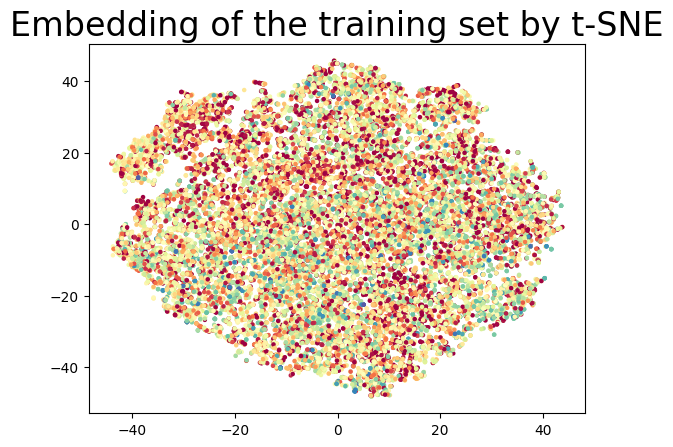

In [ ]:
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=5, c=df['track_popularity'], cmap='Spectral')
plt.title('Embedding of the training set by t-SNE', fontsize=24);
plt.show()

##### Con componentes PCA

In [ ]:
tsne = TSNE(n_components=2,init="pca",learning_rate="auto",n_iter=500,n_iter_without_progress=150,n_jobs=2,random_state=42)
X_tsne = tsne.fit_transform(X_pca_12)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


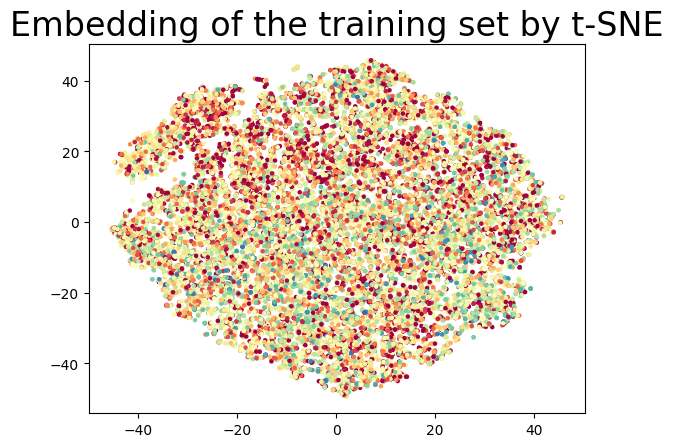

In [ ]:
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=5, c=df['track_popularity'], cmap='Spectral')
plt.title('Embedding of the training set by t-SNE', fontsize=24);
plt.show()

En ambos casos obtuvimos lo mismo

#### UMAP

In [ ]:
!pip install umap-learn
import umap.umap_ as umap

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, df['track_popularity'], test_size=0.2, random_state=42)

trans = umap.UMAP(n_neighbors=5, random_state=42).fit(X_train)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisati

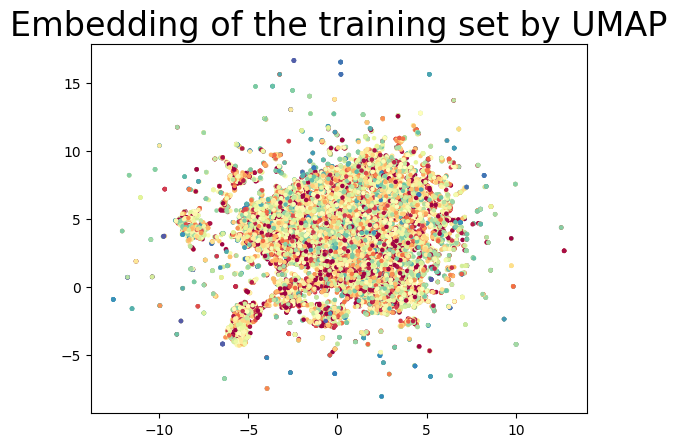

In [ ]:
plt.scatter(trans.embedding_[:, 0], trans.embedding_[:, 1], s= 5, c=y_train, cmap='Spectral')
plt.title('Embedding of the training set by UMAP', fontsize=24);

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
svc = SVC().fit(trans.embedding_, y_train)
knn = KNeighborsClassifier().fit(trans.embedding_, y_train)

In [ ]:
%time test_embedding = trans.transform(X_test)

CPU times: user 16.7 s, sys: 439 ms, total: 17.2 s
Wall time: 20.9 s


Text(0.5, 1.0, 'Embedding of the test set by UMAP')

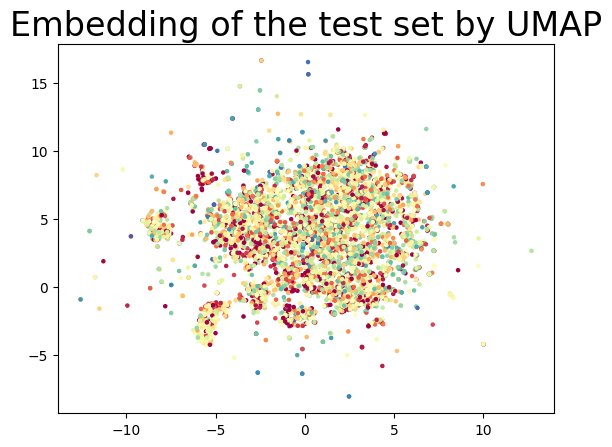

In [ ]:
plt.scatter(test_embedding[:, 0], test_embedding[:, 1], s= 5, c=y_test, cmap='Spectral')
plt.title('Embedding of the test set by UMAP', fontsize=24)

In [ ]:
svc.score(trans.transform(X_test), y_test), knn.score(trans.transform(X_test), y_test)

(0.07157814582143537, 0.0774795355035218)

#### Isomap

In [ ]:
from sklearn.manifold import Isomap # for Isomap dimensionality reduction

In [ ]:
### Step 1 - Configure the Isomap function, note we use default hyperparameter values in this example
embed3 = Isomap(
    n_neighbors=5, # default=5, algorithm finds local structures based on the nearest neighbors
    n_components=10, # number of dimensions
    eigen_solver='auto', # {‘auto’, ‘arpack’, ‘dense’}, default=’auto’
    tol=0, # default=0, Convergence tolerance passed to arpack or lobpcg. not used if eigen_solver == ‘dense’.
    max_iter=None, # default=None, Maximum number of iterations for the arpack solver. not used if eigen_solver == ‘dense’.
    path_method='auto', # {‘auto’, ‘FW’, ‘D’}, default=’auto’, Method to use in finding shortest path.
    neighbors_algorithm='auto', # neighbors_algorithm{‘auto’, ‘brute’, ‘kd_tree’, ‘ball_tree’}, default=’auto’
    n_jobs=-1, # n_jobsint or None, default=None, The number of parallel jobs to run. -1 means using all processors
    metric='minkowski', # string, or callable, default=”minkowski”
    p=2, # default=2, Parameter for the Minkowski metric. When p = 1, this is equivalent to using manhattan_distance (l1), and euclidean_distance (l2) for p = 2
    metric_params=None # default=None, Additional keyword arguments for the metric function.
)

### Step 2 - Fit the data and transform it, so we have 3 dimensions instead of 64
X_trans3 = embed3.fit_transform(X_raw)

### Step 3 - Print shape to test
print('The new shape of X: ',X_trans3.shape)

Se truncaron las últimas líneas 5000 del resultado de transmisión.
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/usr/local/lib/python

#### K-Means

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import silhouette_score

# k-Medias
nMin=2
nMax=10
rango=np.arange(nMin,nMax)
iners=[]
CHs=[]
DBs=[]
Sils=[]
for k in rango:
  kM_Aux=KMeans(n_clusters=k)
  kM_Aux.fit(X_pca_12)
  iner_Aux=kM_Aux.inertia_
  iners.append(iner_Aux)
  labs_kM_Aux=kM_Aux.labels_
  CH_Aux=calinski_harabasz_score(X_pca_12,labs_kM_Aux)
  CHs.append(CH_Aux)
  DB_Aux=davies_bouldin_score(X_pca_12,labs_kM_Aux)
  DBs.append(DB_Aux)
  Sil_Aux=silhouette_score(X_pca_12,labs_kM_Aux)
  Sils.append(Sil_Aux)

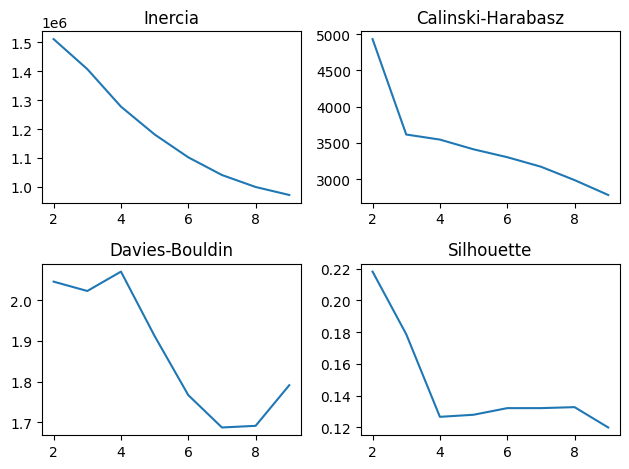

In [ ]:
df_kM=pd.DataFrame({"k":np.arange(nMin,nMax),"inercia":iners,"C-H":CHs,"D-B":DBs,"Sil":Sils})
df_kM["Método"]=["k-Means"]*df_kM.shape[0]
df_kM_L=df_kM.melt(id_vars=["k"], value_vars=["inercia","C-H","D-B","Sil"])

fig,axs=plt.subplots(nrows=2,ncols=2,sharey=False)
axs[0,0].plot(df_kM["k"],df_kM["inercia"])
axs[0,0].set_title("Inercia")
axs[0,1].plot(df_kM["k"],df_kM["C-H"])
axs[0,1].set_title("Calinski-Harabasz")
axs[1,0].plot(df_kM["k"],df_kM["D-B"])
axs[1,0].set_title("Davies-Bouldin")
axs[1,1].plot(df_kM["k"],df_kM["Sil"])
axs[1,1].set_title("Silhouette")
fig.tight_layout()
plt.show()

Probamos con 2 y con 5 clusters

In [ ]:
kM_Aux2=KMeans(n_clusters=2)
kM_Aux2.fit(X_pca_12)
df['cluster_2'] = kM_Aux2.labels_

kM_Aux5=KMeans(n_clusters=5)
kM_Aux5.fit(X_pca_12)
df['cluster_5'] = kM_Aux5.labels_

In [ ]:
df.groupby('cluster_2')['track_popularity'].describe()

,count,mean,std,min,25%,50%,75%,max
cluster_2,,,,,,,,
0,19141.0,44.752312,25.366983,0.0,27.0,49.0,65.0,99.0
1,7120.0,44.012781,23.931088,0.0,29.0,47.0,62.0,100.0


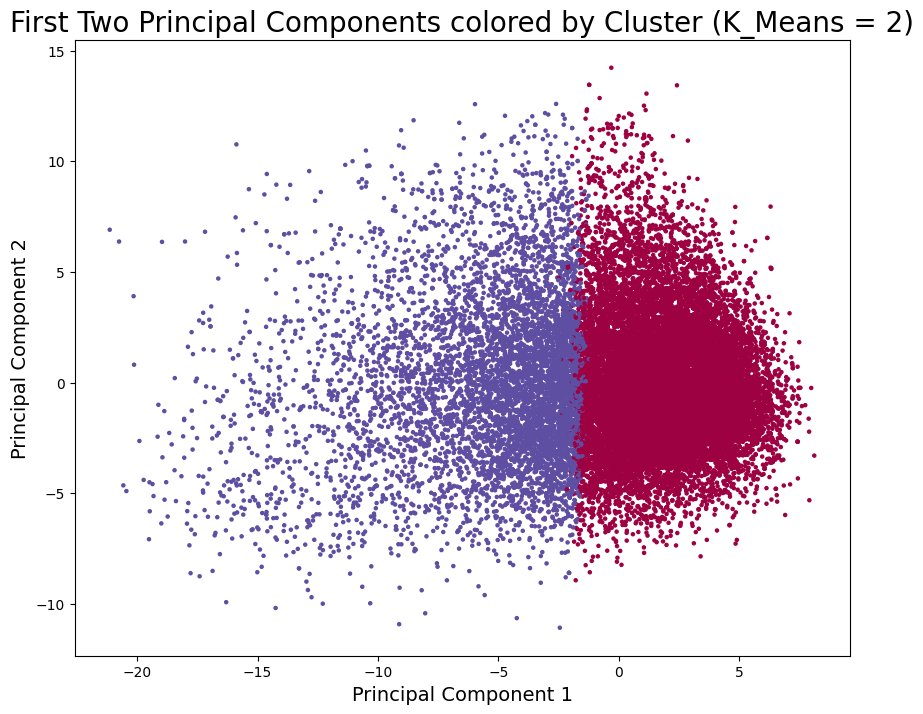

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(X_pca_12[:, 0], X_pca_12[:, 1], s=5, c=df['cluster_2'], cmap='Spectral')
plt.title('First Two Principal Components colored by Cluster (K_Means = 2)', fontsize=20)
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)
plt.show()

In [ ]:
df.groupby('cluster_5')['track_popularity'].describe()

,count,mean,std,min,25%,50%,75%,max
cluster_5,,,,,,,,
0,1222.0,38.692308,21.517384,0.0,24.0,44.0,54.0,97.0
1,10087.0,45.935561,25.525619,0.0,28.0,51.0,66.0,98.0
2,4994.0,44.446536,24.467803,0.0,28.0,48.0,63.0,100.0
3,3663.0,44.616162,25.151145,0.0,28.0,48.0,64.0,98.0
4,6295.0,43.518030,24.846109,0.0,25.5,47.0,63.0,99.0


/tmp/ipykernel_26556/2750184211.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


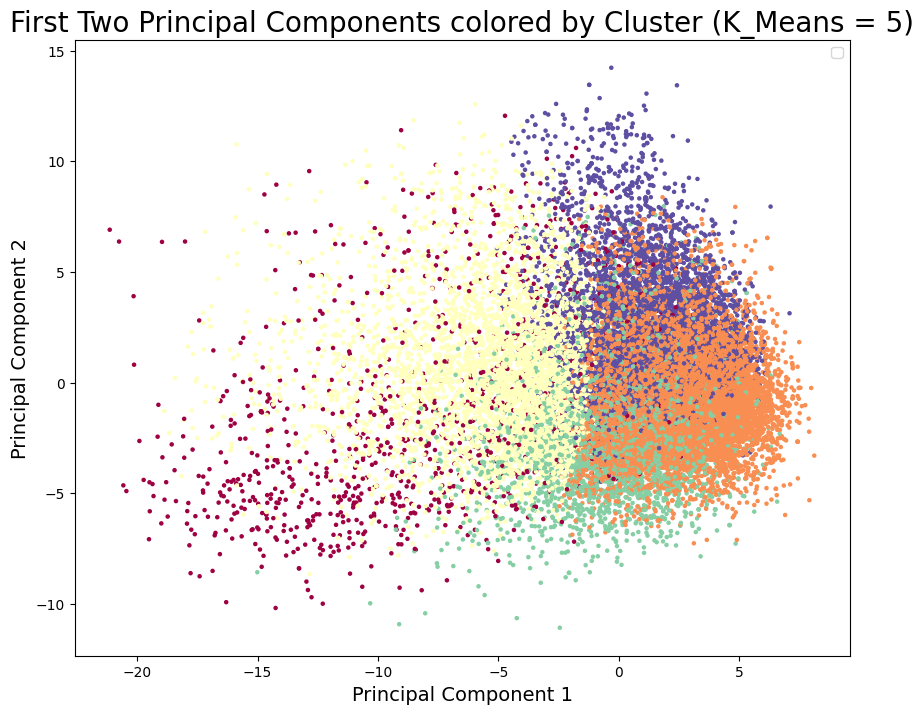

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(X_pca_12[:, 0], X_pca_12[:, 1], s=5, c=df['cluster_5'], cmap='Spectral')
plt.title('First Two Principal Components colored by Cluster (K_Means = 5)', fontsize=20)
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)
plt.show()

### Prediccion 0s

#### Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

X = df.select_dtypes(include='number').drop(columns=['es0','track_popularity', 'anio'])
# Target
y = df['es0']

# Split the data into training and testing sets
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=500, max_depth=15, min_samples_split=20,
                                       min_samples_leaf=5, class_weight='balanced', random_state=42, n_jobs=-1)
rf_classifier.fit(X_train_rf, y_train_rf)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=5, min_samples_split=20,
                       n_estimators=500, n_jobs=-1, random_state=42)

In [ ]:
# Evaluate the model
print('TRAIN')
y_pred_rf = rf_classifier.predict(X_train_rf)
print("Random Forest Classifier Report:")
print(classification_report(y_train_rf, y_pred_rf))
print(f"Accuracy: {accuracy_score(y_train_rf, y_pred_rf):.4f}")

print('TEST')
y_pred_rf = rf_classifier.predict(X_test_rf)
print("Random Forest Classifier Report:")
print(classification_report(y_test_rf, y_pred_rf))
print(f"Accuracy: {accuracy_score(y_test_rf, y_pred_rf):.4f}")

TRAIN
Random Forest Classifier Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     19492
           1       0.84      0.98      0.90      1516

    accuracy                           0.99     21008
   macro avg       0.92      0.98      0.95     21008
weighted avg       0.99      0.99      0.99     21008

Accuracy: 0.9850
TEST
Random Forest Classifier Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      4874
           1       0.28      0.15      0.20       379

    accuracy                           0.91      5253
   macro avg       0.61      0.56      0.58      5253
weighted avg       0.89      0.91      0.90      5253

Accuracy: 0.9105


In [ ]:
max_depths = [tree.get_depth() for tree in rf_classifier.estimators_]
print(f"Max depth of individual trees in the Random Forest: {max(max_depths)}")
print(f"Min depth of individual trees in the Random Forest: {min(max_depths)}")

Max depth of individual trees in the Random Forest: 10
Min depth of individual trees in the Random Forest: 10


#### CatBoost Classifier

In [26]:
X = df.drop(columns=['es0','track_popularity', 'track_popularity_bins', 'anio', 'track_album_release_date',
                     'Unnamed: 0', 'track_id', 'track_name', 'track_album_id', 'track_album_name',
                     'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre'])
# Target
y = df['es0']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

train_pool = Pool(X_train, y_train, cat_features=X.select_dtypes(include='object').columns.to_list())

In [28]:
catboost_c = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.02,
    loss_function='Logloss',
    eval_metric='Recall',
    random_seed=42,
    verbose=500)

# ── ENTRENAMIENTO ──────────────────────────────────────────────
catboost_c.fit(train_pool)

0:	learn: 0.0000000	total: 73.3ms	remaining: 1m 13s
500:	learn: 0.2486807	total: 41.5s	remaining: 41.3s
999:	learn: 0.2843008	total: 1m 39s	remaining: 0us


CatBoostClassifier(eval_metric='Recall', iterations=1000, learning_rate=0.02, loss_function='Logloss', random_seed=42, verbose=500)

In [30]:
# Evaluate the model
print('TRAIN')
y_pred = catboost_c.predict(X_train)
print("Catboost Classifier Report:")
print(classification_report(y_train, y_pred))
print(f"Accuracy: {accuracy_score(y_train, y_pred):.4f}")

print('TEST')
y_pred = catboost_c.predict(X_test)
print("Catboost Classifier Report:")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

TRAIN
Catboost Classifier Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     19492
           1       0.97      0.72      0.82      1516

    accuracy                           0.98     21008
   macro avg       0.97      0.86      0.91     21008
weighted avg       0.98      0.98      0.98     21008

Accuracy: 0.9778
TEST
Catboost Classifier Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97      4874
           1       0.79      0.25      0.38       379

    accuracy                           0.94      5253
   macro avg       0.86      0.62      0.67      5253
weighted avg       0.93      0.94      0.93      5253

Accuracy: 0.9410


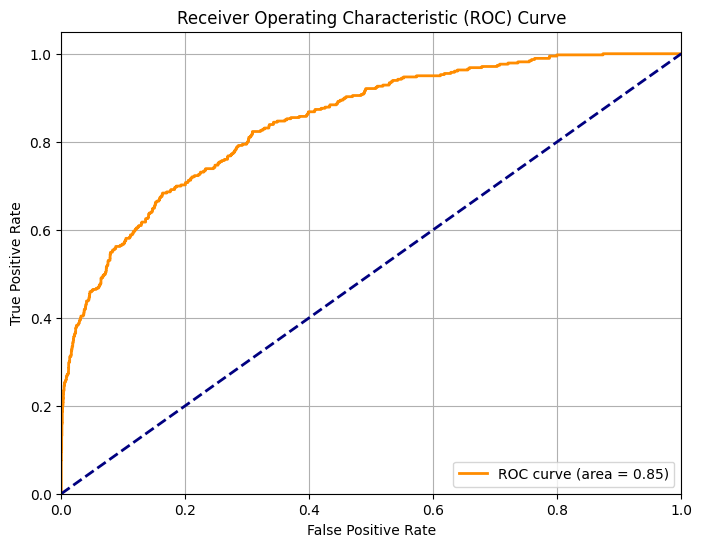

In [32]:
# Get predicted probabilities for the positive class (class 1)
y_pred_proba = catboost_c.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

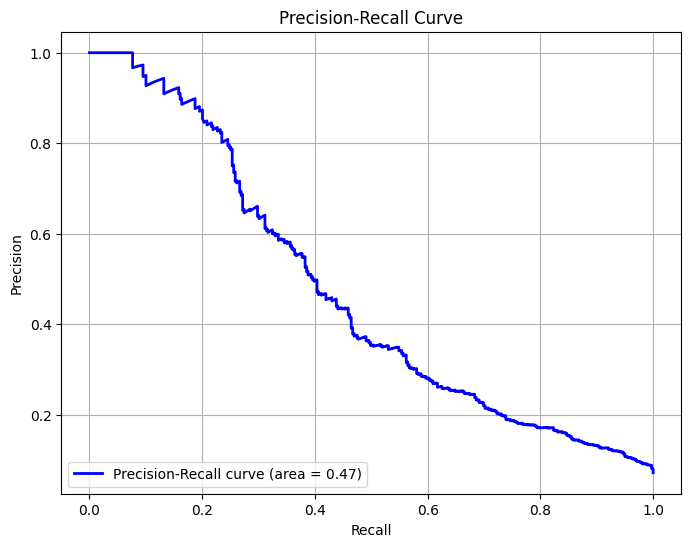

In [35]:
# Get predicted probabilities for the positive class (class 1)
y_pred_proba = catboost_c.predict_proba(X_test)[:, 1]

# Calculate Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Calculate Area Under the Curve (AUC) for Precision-Recall
pr_auc = auc(recall, precision)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall curve (area = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

In [37]:
# Get predicted probabilities for the positive class (class 1)
y_pred_proba = catboost_c.predict_proba(X_test)[:, 1]

# --- Optimal Threshold for ROC Curve (maximizing TPR - FPR) ---
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)

# Find the optimal threshold for ROC curve (Youden's J statistic)
optimal_idx_roc = np.argmax(tpr - fpr)
optimal_threshold_roc = thresholds_roc[optimal_idx_roc]
print(f"Optimal Threshold (ROC - Max (TPR - FPR)): {optimal_threshold_roc:.4f}")

# --- Optimal Threshold for Precision-Recall Curve (maximizing F1-score) ---
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)

# Calculate F1-scores for each threshold
f_scores = 2 * (precision * recall) / (precision + recall)

# Handle potential NaN values where precision + recall = 0
f_scores[np.isnan(f_scores)] = 0

# Find the optimal threshold for PR curve (maximizing F1-score)
optimal_idx_pr = np.argmax(f_scores)
optimal_threshold_pr = thresholds_pr[optimal_idx_pr]

print(f"Optimal Threshold (Precision-Recall - Max F1-score): {optimal_threshold_pr:.4f}")

Optimal Threshold (ROC - Max (TPR - FPR)): 0.0899
Optimal Threshold (Precision-Recall - Max F1-score): 0.2697


In [51]:
# Definimos threshold -> si queda 1 es porque predecimos ese valor como cero (0) -> si queda 0, predecimos el valor con el modelo
pred_binary_kaggle_set = catboost_c.predict_proba(df_val[X_train.columns])[:,1]
modelo_o_no = (pred_binary_kaggle_set > optimal_threshold_pr).astype(int)

In [43]:
X_reg = df.drop(columns=['track_popularity','Unnamed: 0','anio','es0', 'track_popularity_bins','key','mode',
                         'track_id', 'track_name','track_album_id', 'track_album_name','track_album_release_date',
                         'playlist_name', 'playlist_id'])
y_reg = df['track_popularity']

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

train_pool = Pool(X_reg_train, y_reg_train, cat_features=X_reg.select_dtypes(include='object').columns.to_list())

In [45]:
catboost_r = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.025,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=500
)

# ── ENTRENAMIENTO ──────────────────────────────────────────────
catboost_r.fit(train_pool)

print('TRAIN')
y_reg_pred = catboost_r.predict(X_reg_train)
print(f"R²:   {r2_score(y_reg_train, y_reg_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_train, y_reg_pred)):.4f}")

print('TEST')
y_reg_pred = catboost_r.predict(X_reg_test)
print(f"R²:   {r2_score(y_reg_test, y_reg_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_test, y_reg_pred)):.4f}")

0:	learn: 0.0094409	total: 253ms	remaining: 4m 12s
500:	learn: 0.4193262	total: 48.7s	remaining: 48.6s
999:	learn: 0.4662530	total: 1m 58s	remaining: 0us
TRAIN
R²:   0.6255
RMSE: 15.2799
TEST
R²:   0.4101
RMSE: 19.2465


In [46]:
y_reg_kaggle = catboost_r.predict(df_val[X_reg.columns])

In [52]:
y_final_classif_reg = [0 if i==1 else j for i,j in zip(modelo_o_no, y_reg_kaggle)]

In [58]:
pd.DataFrame({'ID':df_val['Unnamed: 0'], 'track_popularity':y_final_classif_reg}).to_csv('catboost_classif_catboost_reg.csv', index=False)

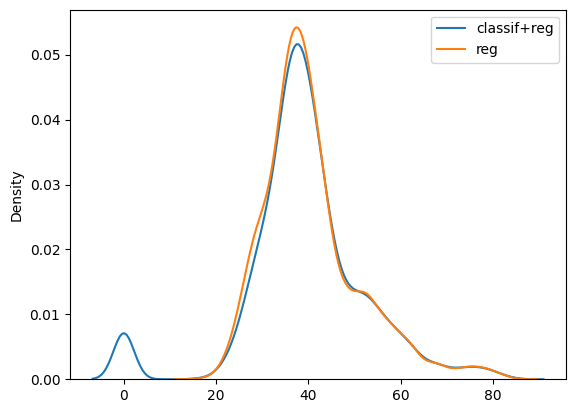

In [56]:
sns.kdeplot(y_final_classif_reg, label='classif+reg')
sns.kdeplot(y_reg_kaggle, label='reg')
plt.legend()
plt.show()

Probamos con otros parametros, pero no da mejor

In [64]:
catboost_r_adj = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    subsample=0.8,
    depth=6,
    verbose=200
)

# ── ENTRENAMIENTO ──────────────────────────────────────────────
catboost_r_adj.fit(train_pool)

print('TRAIN')
y_reg_adj_pred = catboost_r_adj.predict(X_reg_train)
print(f"R²:   {r2_score(y_reg_train, y_reg_adj_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_train, y_reg_adj_pred)):.4f}")

print('TEST')
y_reg_adj_pred = catboost_r_adj.predict(X_reg_test)
print(f"R²:   {r2_score(y_reg_test, y_reg_adj_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_test, y_reg_adj_pred)):.4f}")

0:	learn: 0.0186446	total: 133ms	remaining: 39.9s
200:	learn: 0.4013094	total: 28.4s	remaining: 14s
299:	learn: 0.4252617	total: 35.7s	remaining: 0us
TRAIN
R²:   0.5945
RMSE: 15.8992
TEST
R²:   0.4016
RMSE: 19.3848


### New_FE

In [91]:
df = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Datasets/df_train_1_FE.csv')

df_val2 = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Datasets/df_val_2_FE_sinOutliers.csv')

df.dropna(inplace=True)

df['len_playlist_name'] = df['playlist_name'].apply(len)
df['tonality'] = df['key'].astype(str) + '_' + df['mode'].astype(str)
df['key'] = df['key'].astype(str)
df['mode'] = df['mode'].astype(str)
df['grupo_anio'] = df['grupo_anio'].astype(str)
df['len_playlist_name'] = df['len_playlist_name'].astype(str)
df['tonality'] = df['tonality'].astype(str)

df_val['loudness'] = df_val['new_loudness']
df_val['liveness'] = df_val['new_liveness']
df_val['duration_min'] = df_val['new_duration_mins']

#### Medias de genero

Volvemos a leer los datasets y armamos features de distancia de la media, pero a cada registro calculamos la distancia con la media de su genero y no de todo el dataset

Hacemos Feature Engineering:

In [70]:
df['distance_mean_danceability'] = (df['danceability'] - df.groupby('playlist_genre')['danceability'].transform('mean'))
df['distance_sq_mean_danceability'] = (df['distance_mean_danceability'])**2

df['distance_mean_energy'] = (df['energy'] - df.groupby('playlist_genre')['energy'].transform('mean'))
df['distance_sq_mean_energy'] = (df['distance_mean_energy'])**2

df['distance_mean_loudness'] = (df['loudness'] - df.groupby('playlist_genre')['loudness'].transform('mean'))
df['distance_sq_mean_loudness'] = (df['distance_mean_loudness'])**2

df['distance_mean_speechiness'] = (df['speechiness'] - df.groupby('playlist_genre')['speechiness'].transform('mean'))
df['distance_sq_mean_speechiness'] = (df['distance_mean_speechiness'])**2

df['distance_mean_acousticness'] = (df['acousticness'] - df.groupby('playlist_genre')['acousticness'].transform('mean'))
df['distance_sq_mean_acousticness'] = (df['distance_mean_acousticness'])**2

df['distance_mean_liveness'] = (df['liveness'] - df.groupby('playlist_genre')['liveness'].transform('mean'))
df['distance_sq_mean_liveness'] = (df['distance_mean_liveness'])**2

df['distance_mean_valence'] = (df['valence'] - df.groupby('playlist_genre')['valence'].transform('mean'))
df['distance_sq_mean_valence'] = (df['distance_mean_valence'])**2

df['distance_mean_tempo'] = (df['tempo'] - df.groupby('playlist_genre')['tempo'].transform('mean'))
df['distance_sq_mean_tempo'] = (df['distance_mean_tempo'])**2

df['distance_mean_duration_min'] = (df['duration_min'] - df.groupby('playlist_genre')['duration_min'].transform('mean'))
df['distance_sq_mean_duration_min'] = (df['distance_mean_duration_min'])**2

audio_features = ['danceability', 'energy', 'loudness',
                  'tempo', 'valence', 'acousticness',
                  'instrumentalness', 'speechiness', 'duration_min']

# Z-score por genero
for col in audio_features:
    mean_by_genre = df.groupby('playlist_genre')[col].transform('mean')
    std_by_genre  = df.groupby('playlist_genre')[col].transform('std')
    df[f'z_{col}'] = (df[col] - mean_by_genre) / std_by_genre

# Rareza total: qué tan lejos está del "sonido promedio global"
z_cols = [f'z_{c}' for c in audio_features]
df['global_atipicality']    = np.sqrt((df[z_cols] ** 2).sum(axis=1))

# Rareza máxima: en qué feature es más extrema la canción
df['max_z_score'] = df[z_cols].abs().max(axis=1)

# En qué dimensión es más rara (puede capturar "tipo de rareza")
df['most_extreme_feature'] = df[z_cols].abs().idxmax(axis=1)

Para set de Kaggle:

In [85]:
# 1. Calculate genre-specific means and stds from the training DataFrame (df)
genre_means_df_train = df.groupby('playlist_genre')[audio_features].mean()
genre_stds_df_train = df.groupby('playlist_genre')[audio_features].std()

# 2. Iterate over audio_features to create new features for df_val
for col in audio_features:
    # Get the mean and std for each genre directly from df_val
    # These will be the default values, to be used for genres not in training set
    mean_from_val = df_val.groupby('playlist_genre')[col].transform('mean')
    std_from_val = df_val.groupby('playlist_genre')[col].transform('std')

    # Create a mask for genres present in both df_val and df_train
    mask_genre_in_train = df_val['playlist_genre'].isin(genre_means_df_train.index)

    # Use .map to get the training stats for rows where the genre is in train
    mapped_mean_from_train = df_val['playlist_genre'].map(genre_means_df_train[col])
    mapped_std_from_train = df_val['playlist_genre'].map(genre_stds_df_train[col])

    # Combine: prioritize training stats where genre exists in train, otherwise use val stats
    effective_mean = mean_from_val.copy()
    effective_std = std_from_val.copy()

    effective_mean.loc[mask_genre_in_train] = mapped_mean_from_train.loc[mask_genre_in_train]
    effective_std.loc[mask_genre_in_train] = mapped_std_from_train.loc[mask_genre_in_train]

    # Calculate distance features for df_val using the effective means
    df_val[f'distance_mean_{col}'] = df_val[col] - effective_mean
    df_val[f'distance_sq_mean_{col}'] = (df_val[f'distance_mean_{col}'])**2

    # Calculate Z-score for df_val using the effective means and stds
    # Handle division by zero for std (e.g., if a genre has uniform values)
    df_val[f'z_{col}'] = (df_val[col] - effective_mean) / effective_std.replace(0, np.nan)
    df_val[f'z_{col}'] = df_val[f'z_{col}'].fillna(0) # Fill NaNs (e.g., from std=0) with 0

# Rareza total: qué tan lejos está del "sonido promedio global" para df_val
z_cols_val = [f'z_{c}' for c in audio_features]
df_val['global_atipicality']    = np.sqrt((df_val[z_cols_val] ** 2).sum(axis=1))

# Rareza máxima: en qué feature es más extrema la canción para df_val
df_val['max_z_score'] = df_val[z_cols_val].abs().max(axis=1)

# En qué dimensión es más rara (puede capturar "tipo de rareza") para df_val
df_val['most_extreme_feature'] = df_val[z_cols_val].abs().idxmax(axis=1)

Armamos el modelo

In [73]:
X = df.drop(columns=['Unnamed: 0', 'track_id', 'track_name', 'track_artist','track_popularity','track_album_id',
                     'track_album_name','track_album_release_date', 'playlist_name', 'playlist_id','playlist_genre',
                     'playlist_subgenre', 'anio','es0', 'track_popularity_bins'])
y = df['track_popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

cat_features=X.select_dtypes(include='object').columns.to_list()
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

In [74]:
c_regressor = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.025,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=200,
    early_stopping_rounds=100
)

c_regressor.fit(train_pool, eval_set=val_pool)

print('TRAIN')
y_pred = c_regressor.predict(X_train)
print(f"R²: {r2_score(y_train, y_pred):.4f}")

print('VAL')
y_pred = c_regressor.predict(X_val)
print(f"R²: {r2_score(y_val, y_pred):.4f}")

print('TEST')
y_pred = c_regressor.predict(X_test)
print(f"R²: {r2_score(y_test, y_pred):.4f}")

0:	learn: 0.0052107	test: 0.0046552	best: 0.0046552 (0)	total: 94.8ms	remaining: 1m 34s
200:	learn: 0.1992235	test: 0.1642649	best: 0.1642649 (200)	total: 16.5s	remaining: 1m 5s
400:	learn: 0.2406033	test: 0.1803580	best: 0.1803580 (400)	total: 30.4s	remaining: 45.4s
600:	learn: 0.2820358	test: 0.1929336	best: 0.1929336 (600)	total: 44.6s	remaining: 29.6s
800:	learn: 0.3155600	test: 0.1987901	best: 0.1988103 (797)	total: 1m	remaining: 14.9s
999:	learn: 0.3448522	test: 0.2031802	best: 0.2032452 (989)	total: 1m 14s	remaining: 0us

bestTest = 0.2032451709
bestIteration = 989

Shrink model to first 990 iterations.
TRAIN
R²: 0.3416
VAL
R²: 0.2032
TEST
R²: 0.2239


In [77]:
pd.DataFrame({'Var':X_train.columns, 'Importancia': c_regressor.feature_importances_}).sort_values(by='Importancia', ascending=False)

,Var,Importancia
35,track_age,12.039021
12,grupo_anio,9.786592
36,len_playlist_name,7.495608
46,z_instrumentalness,6.991392
3,loudness,4.836187
5,speechiness,2.922774
7,instrumentalness,2.303252
17,distance_mean_loudness,2.064342
1,energy,2.059144
15,distance_mean_energy,1.928050


##### Con vars overfitting

In [78]:
X = df.drop(columns=['Unnamed: 0', 'track_name', 'track_popularity','track_album_name','track_album_release_date',
                     'playlist_subgenre', 'anio','es0', 'track_popularity_bins'])
y = df['track_popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

cat_features=X.select_dtypes(include='object').columns.to_list()
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

In [79]:
c_regressor = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.025,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=200,
    early_stopping_rounds=100
)

c_regressor.fit(train_pool, eval_set=val_pool)

print('TRAIN')
y_pred = c_regressor.predict(X_train)
print(f"R²: {r2_score(y_train, y_pred):.4f}")

print('VAL')
y_pred = c_regressor.predict(X_val)
print(f"R²: {r2_score(y_val, y_pred):.4f}")

print('TEST')
y_pred = c_regressor.predict(X_test)
print(f"R²: {r2_score(y_test, y_pred):.4f}")

0:	learn: 0.0143137	test: 0.0151398	best: 0.0151398 (0)	total: 200ms	remaining: 3m 19s
200:	learn: 0.4809161	test: 0.5289185	best: 0.5289185 (200)	total: 23.5s	remaining: 1m 33s
400:	learn: 0.5085842	test: 0.5461546	best: 0.5461546 (400)	total: 46.4s	remaining: 1m 9s
600:	learn: 0.5308237	test: 0.5526173	best: 0.5526513 (598)	total: 1m 12s	remaining: 48.3s
800:	learn: 0.5479328	test: 0.5558297	best: 0.5558297 (800)	total: 1m 27s	remaining: 21.7s
999:	learn: 0.5633380	test: 0.5572119	best: 0.5572471 (973)	total: 1m 42s	remaining: 0us

bestTest = 0.5572471487
bestIteration = 973

Shrink model to first 974 iterations.
TRAIN
R²: 0.7886
VAL
R²: 0.5572
TEST
R²: 0.5605


In [80]:
pd.DataFrame({'Var':X_train.columns, 'Importancia': c_regressor.feature_importances_}).sort_values(by='Importancia', ascending=False)

,Var,Importancia
2,track_album_id,25.722773
4,playlist_id,12.724443
0,track_id,8.874043
3,playlist_name,8.846737
1,track_artist,7.036313
18,grupo_anio,6.158558
41,track_age,4.663090
42,len_playlist_name,2.518733
5,playlist_genre,2.493508
9,loudness,0.964326


##### Submission

In [87]:
y_pred = c_regressor.predict(df_val[X_train.columns])

In [89]:
pd.DataFrame({'ID':df_val['Unnamed: 0'], 'track_popularity':y_pred}).to_csv('catboost_FE_by_genre.csv', index=False)

##### Kaggle results & Comparacion predicciones de esta notebook

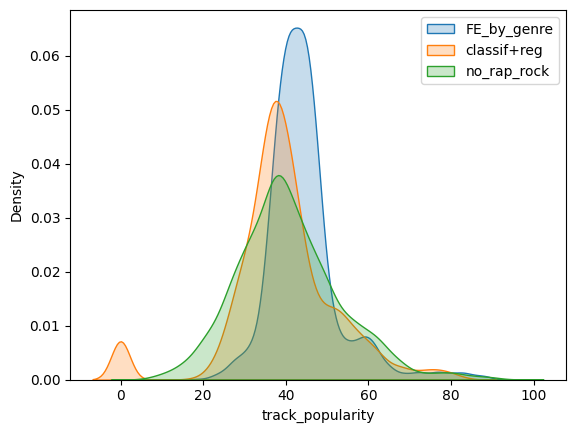

In [90]:
pred_FE_by_genre = pd.read_csv('/content/catboost_FE_by_genre.csv')
pred_classif_reg = pd.read_csv('/content/catboost_classif_catboost_reg.csv')
pred_no_rock_no_rap = pd.read_csv('/content/catboost_no_rap_rock.csv')

sns.kdeplot(pred_FE_by_genre['track_popularity'], label='FE_by_genre', fill=True)
sns.kdeplot(pred_classif_reg['track_popularity'], label='classif+reg', fill=True)
sns.kdeplot(pred_no_rock_no_rap['track_popularity'], label='no_rap_rock', fill=True)
plt.legend()
plt.show()

#### Medias del grupo anio

##### Mini analisis

No se ven patrones evidentes

In [104]:
df.groupby(['grupo_anio']).mean(numeric_only=True)

,Unnamed: 0,track_popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,anio,es0,distance_mean_danceability,distance_sq_mean_danceability,distance_mean_energy,distance_sq_mean_energy,distance_mean_loudness,distance_sq_mean_loudness,distance_mean_speechiness,distance_sq_mean_speechiness,distance_mean_acousticness,distance_sq_mean_acousticness,distance_mean_liveness,distance_sq_mean_liveness,distance_mean_valence,distance_sq_mean_valence,distance_mean_tempo,distance_sq_mean_tempo,distance_mean_duration_ms,distance_sq_mean_duration_ms,dance_energy,happy_energy,acoustic_instr,duration_min,track_age,distance_mean_duration_min,distance_sq_mean_duration_min,z_danceability,z_energy,z_loudness,z_tempo,z_valence,z_acousticness,z_instrumentalness,z_speechiness,z_duration_min,global_atipicality,max_z_score
grupo_anio,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1970,13611.998227,47.143617,0.534474,0.641708,-9.539580,0.054773,0.248363,0.054754,0.190240,0.612957,123.228248,248256.982654,1973.630319,0.044326,-1.318882e-17,0.020478,-5.595406e-17,0.037888,8.897532e-17,9.770980,-5.708594e-18,0.001997,2.372019e-17,0.057526,1.969711e-17,0.027464,-2.608237e-18,0.051135,-9.209339e-15,686.915406,22542.561370,5.386103e+09,0.342028,0.407624,0.013661,4.137616,46.369681,8.267618e-18,1.354982,-8.858162e-17,-2.877919e-16,3.090514e-17,-3.504880e-16,-1.574784e-17,9.980196e-17,-2.066905e-18,-1.314699e-16,1.377936e-17,2.801782,1.791263
1980,14100.431034,44.858150,0.600679,0.704670,-9.246353,0.058319,0.146289,0.049214,0.184125,0.620284,121.997081,264463.531581,1985.083072,0.043887,-2.932172e-17,0.025166,-4.124183e-17,0.036064,6.473401e-16,12.679698,-2.419912e-18,0.002693,-1.183310e-17,0.034450,-4.089379e-18,0.021031,-1.109353e-17,0.048159,2.361051e-15,655.100475,38749.110296,4.204681e+09,0.417569,0.442760,0.006231,4.407726,34.916928,-5.533714e-17,0.750885,-1.839351e-16,-2.206525e-16,1.815423e-16,9.257659e-17,-4.813722e-17,-5.603320e-17,-1.331224e-17,-4.737590e-17,-6.891039e-17,2.790228,1.828937
1990,15455.662412,40.055018,0.670874,0.666053,-8.449716,0.119693,0.141887,0.033293,0.201314,0.598687,115.222956,263900.362567,1994.893486,0.084947,-4.356355e-17,0.025620,1.424428e-17,0.032567,-1.033602e-15,8.900949,1.020066e-17,0.012855,-7.305385e-18,0.035042,-1.294934e-18,0.030148,4.920751e-17,0.045579,-1.170269e-14,834.496276,38185.941282,4.089116e+09,0.446207,0.410944,0.002543,4.398339,25.106514,-3.531995e-16,0.730819,-2.724249e-16,8.317510e-17,-3.469447e-16,-4.044838e-16,2.299119e-16,-3.823912e-17,1.175214e-17,8.829987e-17,-4.179706e-16,2.813993,1.834478
2000,14514.120053,34.826826,0.645336,0.720086,-6.540000,0.115553,0.159521,0.036879,0.202070,0.602414,119.574631,244937.255181,2005.095618,0.175299,1.865116e-17,0.026014,-5.170720e-17,0.029634,4.340633e-17,6.624538,-6.627427e-18,0.011692,3.892415e-18,0.041559,7.475207e-18,0.028081,6.298636e-17,0.046721,5.257828e-15,892.051365,19222.833897,2.928914e+09,0.461326,0.441774,0.006176,4.082288,14.904382,-1.104031e-16,0.710944,1.156519e-16,-2.994506e-16,1.745689e-17,1.758369e-16,2.937262e-16,1.840051e-17,-4.995266e-17,-6.062732e-17,-1.325191e-16,2.813785,1.821570
2010,12285.617364,37.546667,0.628061,0.722795,-6.344006,0.102938,0.157087,0.065699,0.194346,0.544655,121.074631,240926.079547,2012.273178,0.139535,-4.537284e-17,0.020863,5.273990e-17,0.029903,6.743271e-16,6.593595,7.100264e-18,0.010595,9.664965e-18,0.045521,-1.703203e-17,0.025122,3.229114e-17,0.054546,-5.349450e-15,820.689340,15211.658263,2.721491e+09,0.452679,0.404961,0.011880,4.015435,7.726822,-5.046781e-16,0.691693,-3.145288e-16,3.063871e-16,2.634757e-16,-1.852781e-16,1.374009e-16,4.354828e-17,-2.108563e-17,6.953955e-17,-6.024466e-16,2.803812,1.830294
2015,11767.248050,39.363495,0.659115,0.683881,-6.516329,0.106299,0.186857,0.053052,0.186354,0.484715,118.938854,226837.168295,2015.000000,0.104524,1.472215e-18,0.018780,-3.260522e-17,0.029952,-4.364683e-17,6.806670,9.201341e-19,0.010851,3.290833e-18

In [125]:
analisis_tiempo = df.loc[(df['anio']>2017) & (df['track_album_release_date']!='2019'), ['track_album_release_date','anio','track_popularity']]
analisis_tiempo['track_album_release_date'] = pd.to_datetime(analisis_tiempo['track_album_release_date'])
analisis_tiempo['anio'] = analisis_tiempo['track_album_release_date'].dt.year
analisis_tiempo['mes'] = analisis_tiempo['track_album_release_date'].dt.month

# Hacemos analisis de track_popularity por mes
analisis_tiempo.groupby(['anio','mes'])['track_popularity'].describe()

count       mean        std  min    25%   50%    75%    max
anio mes                                                              
2018 1     119.0  42.764706  27.208145  0.0  20.00  46.0  65.00   84.0
     2     155.0  43.251613  23.837271  0.0  28.50  48.0  59.50   83.0
     3     158.0  46.392405  22.580877  0.0  32.25  51.0  62.00   87.0
     4     195.0  47.671795  25.392080  0.0  28.50  52.0  67.00   89.0
     5     193.0  51.124352  22.979272  0.0  38.00  52.0  71.00   82.0
     6     226.0  50.013274  23.466189  0.0  37.00  54.0  68.00   86.0
     7     182.0  43.972527  22.154014  0.0  31.00  47.0  58.75   84.0
     8     257.0  49.241245  24.673100  0.0  35.00  52.0  68.00   89.0
     9     209.0  49.100478  22.927655  0.0  35.00  53.0  68.00   83.0
     10    292.0  53.160959  24.437270  0.0  40.00  56.5  72.00   97.0
     11    298.0  47.721477  25.195524  0.0  31.25  52.5  69.00   86.0
     12    232.0  55.435345  22.064744  0.0  42.75  60.0  72.00   92.0
2019 1     249.0  50.200803  23.435564  0.0  35.00  53.0  68.00   87.0
     2     325.0  48.861538  22.058758  0.0  35.00  53.0  64.00   90.0
     3     361.0  51.249307  22.691259  0.0  35.00  54.0  69.00   95.0
     4     378.0  50.349206  21.212072  0.0  38.00  52.0  67.75   85.0
     5     536.0  53.285448  22.248105  0.0  39.00  55.0  68.25   94.0
     6     506.0  57.387352  21.231029  1.0  42.00  58.0  73.00   93.0
     7     492.0  55.638211  19.830730  0.0  42.00  57.0  69.00   94.0
     8     584.0  55.857877  20.028419  1.0  40.00  56.0  70.00   94.0
     9     624.0  54.317308  20.041737  1.0  40.00  53.0  68.25   98.0
     10    789.0  56.730038  20.407881  3.0  41.00  57.0  72.00  100.0
     11   1055.0  54.973460  19.533343  2.0  41.00  54.0  70.00   98.0
     12    850.0  53.941176  18.637673  5.0  40.00  53.0  67.00   98.0
2020 1     601.0  48.342762  20.132204  0.0  35.00  47.0  62.00   95.0

##### Modelo

Hacemos el Feature Engineering

In [92]:
df['distance_mean_danceability'] = (df['danceability'] - df.groupby('grupo_anio')['danceability'].transform('mean'))
df['distance_sq_mean_danceability'] = (df['distance_mean_danceability'])**2

df['distance_mean_energy'] = (df['energy'] - df.groupby('grupo_anio')['energy'].transform('mean'))
df['distance_sq_mean_energy'] = (df['distance_mean_energy'])**2

df['distance_mean_loudness'] = (df['loudness'] - df.groupby('grupo_anio')['loudness'].transform('mean'))
df['distance_sq_mean_loudness'] = (df['distance_mean_loudness'])**2

df['distance_mean_speechiness'] = (df['speechiness'] - df.groupby('grupo_anio')['speechiness'].transform('mean'))
df['distance_sq_mean_speechiness'] = (df['distance_mean_speechiness'])**2

df['distance_mean_acousticness'] = (df['acousticness'] - df.groupby('grupo_anio')['acousticness'].transform('mean'))
df['distance_sq_mean_acousticness'] = (df['distance_mean_acousticness'])**2

df['distance_mean_liveness'] = (df['liveness'] - df.groupby('grupo_anio')['liveness'].transform('mean'))
df['distance_sq_mean_liveness'] = (df['distance_mean_liveness'])**2

df['distance_mean_valence'] = (df['valence'] - df.groupby('grupo_anio')['valence'].transform('mean'))
df['distance_sq_mean_valence'] = (df['distance_mean_valence'])**2

df['distance_mean_tempo'] = (df['tempo'] - df.groupby('grupo_anio')['tempo'].transform('mean'))
df['distance_sq_mean_tempo'] = (df['distance_mean_tempo'])**2

df['distance_mean_duration_min'] = (df['duration_min'] - df.groupby('grupo_anio')['duration_min'].transform('mean'))
df['distance_sq_mean_duration_min'] = (df['distance_mean_duration_min'])**2

audio_features = ['danceability', 'energy', 'loudness',
                  'tempo', 'valence', 'acousticness',
                  'instrumentalness', 'speechiness', 'duration_min']

# Z-score por genero
for col in audio_features:
    mean_by_genre = df.groupby('grupo_anio')[col].transform('mean')
    std_by_genre  = df.groupby('grupo_anio')[col].transform('std')
    df[f'z_{col}'] = (df[col] - mean_by_genre) / std_by_genre

# Rareza total: qué tan lejos está del "sonido promedio global"
z_cols = [f'z_{c}' for c in audio_features]
df['global_atipicality']    = np.sqrt((df[z_cols] ** 2).sum(axis=1))

# Rareza máxima: en qué feature es más extrema la canción
df['max_z_score'] = df[z_cols].abs().max(axis=1)

# En qué dimensión es más rara (puede capturar "tipo de rareza")
df['most_extreme_feature'] = df[z_cols].abs().idxmax(axis=1)

Armamos el modelo sin variables feas

In [94]:
X = df.drop(columns=['Unnamed: 0', 'track_id', 'track_name', 'track_artist','track_popularity','track_album_id',
                     'track_album_name','track_album_release_date', 'playlist_name', 'playlist_id','playlist_genre',
                     'playlist_subgenre', 'anio','es0', 'track_popularity_bins', 'mode','key'])
y = df['track_popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

cat_features=X.select_dtypes(include='object').columns.to_list()
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

In [95]:
c_regressor = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.025,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=200,
    early_stopping_rounds=100
)

c_regressor.fit(train_pool, eval_set=val_pool)

print('TRAIN')
y_pred = c_regressor.predict(X_train)
print(f"R²: {r2_score(y_train, y_pred):.4f}")

print('VAL')
y_pred = c_regressor.predict(X_val)
print(f"R²: {r2_score(y_val, y_pred):.4f}")

print('TEST')
y_pred = c_regressor.predict(X_test)
print(f"R²: {r2_score(y_test, y_pred):.4f}")

0:	learn: 0.0052734	test: 0.0050367	best: 0.0050367 (0)	total: 132ms	remaining: 2m 12s
200:	learn: 0.1921261	test: 0.1582890	best: 0.1582890 (200)	total: 16.5s	remaining: 1m 5s
400:	learn: 0.2330804	test: 0.1731034	best: 0.1731034 (400)	total: 30.1s	remaining: 45s
600:	learn: 0.2745848	test: 0.1859181	best: 0.1859181 (600)	total: 42.5s	remaining: 28.2s
800:	learn: 0.3092343	test: 0.1948071	best: 0.1948329 (799)	total: 50.7s	remaining: 12.6s
999:	learn: 0.3399706	test: 0.2012806	best: 0.2012806 (999)	total: 1m 6s	remaining: 0us

bestTest = 0.2012806001
bestIteration = 999

TRAIN
R²: 0.3436
VAL
R²: 0.2013
TEST
R²: 0.2133


In [96]:
pd.DataFrame({'Var':X_train.columns, 'Importancia': c_regressor.feature_importances_}).sort_values(by='Importancia', ascending=False)

,Var,Importancia
10,grupo_anio,11.577939
33,track_age,7.930815
34,len_playlist_name,5.773100
40,z_loudness,3.711883
15,distance_mean_loudness,3.616043
1,energy,2.719151
44,z_instrumentalness,2.639009
16,distance_sq_mean_loudness,2.447538
48,max_z_score,2.242114
22,distance_sq_mean_liveness,2.149521


##### Con vars overfitting

In [98]:
X = df.drop(columns=['Unnamed: 0', 'track_name', 'track_popularity','track_album_name','track_album_release_date',
                     'playlist_subgenre', 'anio','es0', 'track_popularity_bins', 'key','mode'])
y = df['track_popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

cat_features=X.select_dtypes(include='object').columns.to_list()
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

Da resultados un poco (apenas) peores que los de overfitting con medias de genero

In [99]:
c_regressor = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.025,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=200,
    early_stopping_rounds=100
)

c_regressor.fit(train_pool, eval_set=val_pool)

print('TRAIN')
y_pred = c_regressor.predict(X_train)
print(f"R²: {r2_score(y_train, y_pred):.4f}")

print('VAL')
y_pred = c_regressor.predict(X_val)
print(f"R²: {r2_score(y_val, y_pred):.4f}")

print('TEST')
y_pred = c_regressor.predict(X_test)
print(f"R²: {r2_score(y_test, y_pred):.4f}")

0:	learn: 0.0140356	test: 0.0151820	best: 0.0151820 (0)	total: 128ms	remaining: 2m 8s
200:	learn: 0.4820356	test: 0.5289263	best: 0.5289263 (200)	total: 21.7s	remaining: 1m 26s
400:	learn: 0.5102144	test: 0.5438460	best: 0.5438593 (398)	total: 38.1s	remaining: 56.9s
600:	learn: 0.5303481	test: 0.5492408	best: 0.5492738 (598)	total: 52s	remaining: 34.5s
800:	learn: 0.5481546	test: 0.5529273	best: 0.5529273 (800)	total: 1m 5s	remaining: 16.2s
999:	learn: 0.5626402	test: 0.5544080	best: 0.5544135 (998)	total: 1m 18s	remaining: 0us

bestTest = 0.5544135093
bestIteration = 998

Shrink model to first 999 iterations.
TRAIN
R²: 0.7882
VAL
R²: 0.5544
TEST
R²: 0.5591


Todas las variables que creamos quedan ampliamente opacadas

In [106]:
pd.DataFrame({'Var':X_train.columns, 'Importancia': c_regressor.feature_importances_}).sort_values(by='Importancia', ascending=False)

,Var,Importancia
2,track_album_id,26.168928
4,playlist_id,12.930342
0,track_id,8.573739
3,playlist_name,8.009966
1,track_artist,6.594044
16,grupo_anio,6.452002
39,track_age,3.769290
5,playlist_genre,2.764364
40,len_playlist_name,2.057735
21,distance_mean_loudness,1.040556
